# TSLA Stock Price Prediction Using an LSTM-Based RNN

This notebook implements the machine-learning workflow for the KIE4031 final summative assessment using Tesla Inc. (`TSLA`) stock data from Yahoo Finance. The task is next-trading-day closing price prediction using an RNN-based model.

Scope included here:

1. Data collection and preprocessing for the past 10 years of TSLA prices.
2. Cleaning, normalization, and sequence conversion for RNN training.
3. LSTM model development and evaluation with suitable regression metrics.
4. Visual comparison of actual and predicted prices.
5. Benchmark comparison against a non-RNN alternative model.

Long-form discussion and critical analysis can be added later in the report.


## 1. Setup

The workflow uses fixed random seeds for reproducibility. Plot files are saved into the `outputs` folder so the results can be reused in the final report.


In [1]:
from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM
from tensorflow.keras.models import Sequential

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

TICKER = "TSLA"
RUN_DATE = pd.Timestamp.today().normalize()
START_DATE = RUN_DATE - pd.DateOffset(years=10)
END_DATE = RUN_DATE + pd.offsets.BDay(1)  # yfinance end date is exclusive

DATA_FILE = Path("TSLA_stock_data.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

YFINANCE_CACHE_DIR = Path(".yfinance_cache")
YFINANCE_CACHE_DIR.mkdir(exist_ok=True)
yf.set_tz_cache_location(str(YFINANCE_CACHE_DIR))

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", "{:,.4f}".format)


## 2. Data Collection and Preprocessing

The notebook downloads the latest available TSLA daily price data from Yahoo Finance for the past 10 years. If the online request is unavailable, it uses the cached TSLA CSV in this project folder and trims it to the most recent 10-year window available.


In [2]:
def load_price_data(ticker, start_date, end_date, data_file):
    start_text = pd.Timestamp(start_date).strftime("%Y-%m-%d")
    end_text = pd.Timestamp(end_date).strftime("%Y-%m-%d")

    try:
        downloaded = yf.download(
            ticker,
            start=start_text,
            end=end_text,
            progress=False,
            auto_adjust=False,
        )
        if downloaded.empty:
            raise ValueError("Yahoo Finance returned an empty dataset.")
        if isinstance(downloaded.columns, pd.MultiIndex):
            downloaded.columns = downloaded.columns.get_level_values(0)
        downloaded.to_csv(data_file)
        data = downloaded
        source = "Yahoo Finance download"
    except Exception as exc:
        if not data_file.exists():
            raise RuntimeError("Yahoo Finance download failed and no cached CSV was found.") from exc
        data = pd.read_csv(data_file, index_col=0, parse_dates=True)
        source = "cached CSV fallback"

    data.index = pd.to_datetime(data.index)
    if getattr(data.index, "tz", None) is not None:
        data.index = data.index.tz_convert(None)
    data = data.sort_index()
    data.columns.name = None
    data = data.loc[(data.index >= pd.Timestamp(start_date)) & (data.index <= pd.Timestamp(end_date))]
    return data, source


raw_data, data_source = load_price_data(TICKER, START_DATE, END_DATE, DATA_FILE)

print(f"Data source used: {data_source}")
print(f"Requested date window: {START_DATE.date()} to {RUN_DATE.date()}")
print(f"Actual data range: {raw_data.index.min().date()} to {raw_data.index.max().date()}")
print(f"Rows: {raw_data.shape[0]:,} | Columns: {raw_data.shape[1]}")
display(raw_data.head())
display(raw_data.tail())


Data source used: Yahoo Finance download
Requested date window: 2016-06-25 to 2026-06-25
Actual data range: 2016-06-27 to 2026-06-24
Rows: 2,512 | Columns: 6


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2016-06-27,13.2367,13.2367,13.2540,12.5247,12.7240,108081000
2016-06-28,13.4527,13.4527,13.6033,13.2940,13.4593,93186000
2016-06-29,14.0127,14.0127,14.1187,13.5333,13.6753,89923500
2016-06-30,14.1520,14.1520,14.2333,13.9347,14.1980,72646500
2016-07-01,14.4333,14.4333,14.5493,13.7333,13.7427,81000000


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-06-17,396.3800,396.3800,405.9400,393.7600,401.5300,43534300
2026-06-18,400.4900,400.4900,402.5200,384.7000,398.1000,58384700
2026-06-22,405.0500,405.0500,414.7500,394.4000,394.8500,47819500
2026-06-23,381.6100,381.6100,392.8700,379.0600,392.6100,50420200
2026-06-24,375.5300,375.5300,384.5800,373.0500,380.0800,36926400


In [3]:
required_columns = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
missing_columns = [col for col in required_columns if col not in raw_data.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

quality_summary = pd.DataFrame({
    "Missing Values": raw_data[required_columns].isna().sum(),
    "Data Type": raw_data[required_columns].dtypes.astype(str),
})
quality_summary.loc[:, "Duplicate Rows In Dataset"] = raw_data.duplicated().sum()

data = raw_data[required_columns].copy()
data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna().drop_duplicates().sort_index()

print(f"Rows after cleaning: {len(data):,}")
display(quality_summary)
display(data.describe().T)


Rows after cleaning: 2,512


,Missing Values,Data Type,Duplicate Rows In Dataset
Open,0,float64,0
High,0,float64,0
Low,0,float64,0
Close,0,float64,0
Adj Close,0,float64,0
Volume,0,int64,0


,count,mean,std,min,25%,50%,75%,max
Open,"2,512.0000",168.3984,138.2026,12.0733,21.7017,182.4150,264.2900,489.8800
High,"2,512.0000",172.0119,141.0143,12.3153,22.1250,185.9300,269.8683,498.8300
Low,"2,512.0000",164.5543,135.1194,11.7993,21.4057,177.8850,258.8483,485.3300
Close,"2,512.0000",168.3561,138.0867,11.9313,21.8100,182.4600,264.3900,489.8800
Adj Close,"2,512.0000",168.3561,138.0867,11.9313,21.8100,182.4600,264.3900,489.8800
Volume,"2,512.0000","114,628,031.4092","72,686,331.9006","24,892,500.0000","69,945,975.0000","95,591,550.0000","131,515,975.0000","914,082,000.0000"


## 3. Exploratory Visual Checks

These plots summarize the TSLA price level, trading volume, and moving-average behavior before model training.


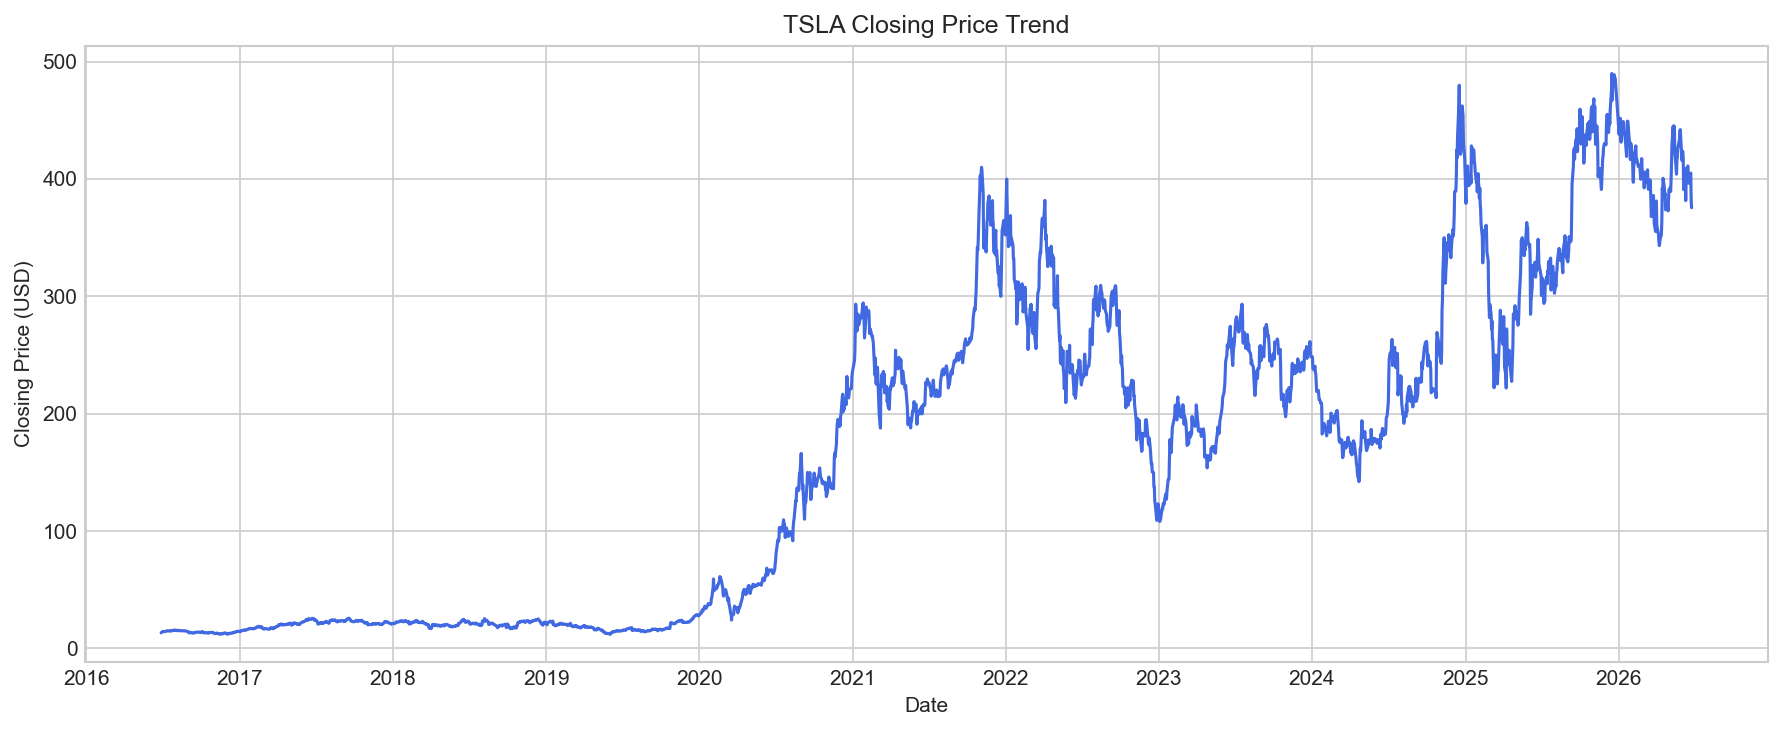

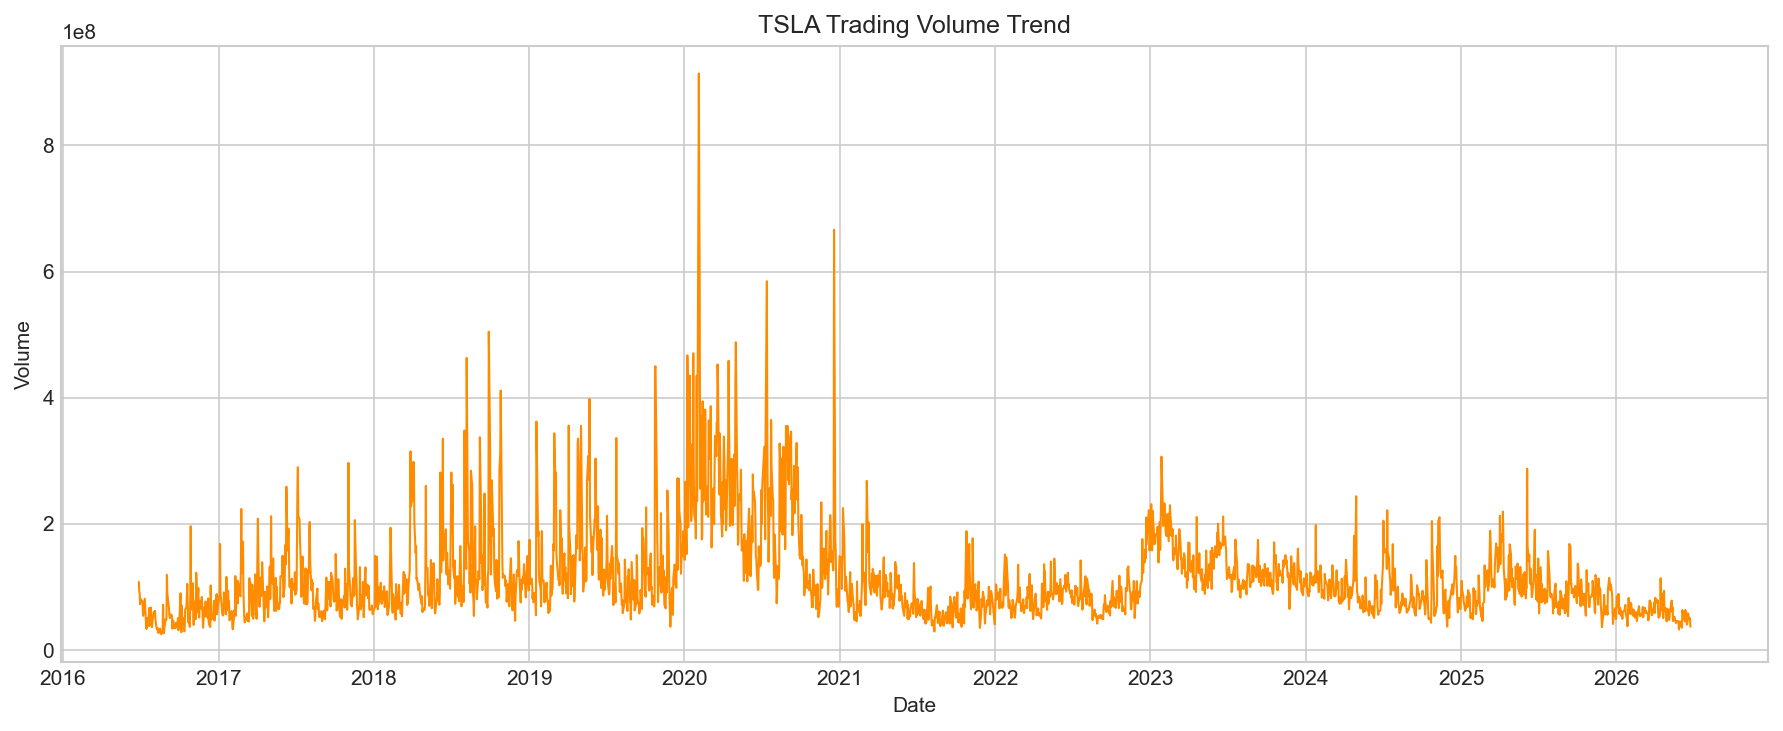

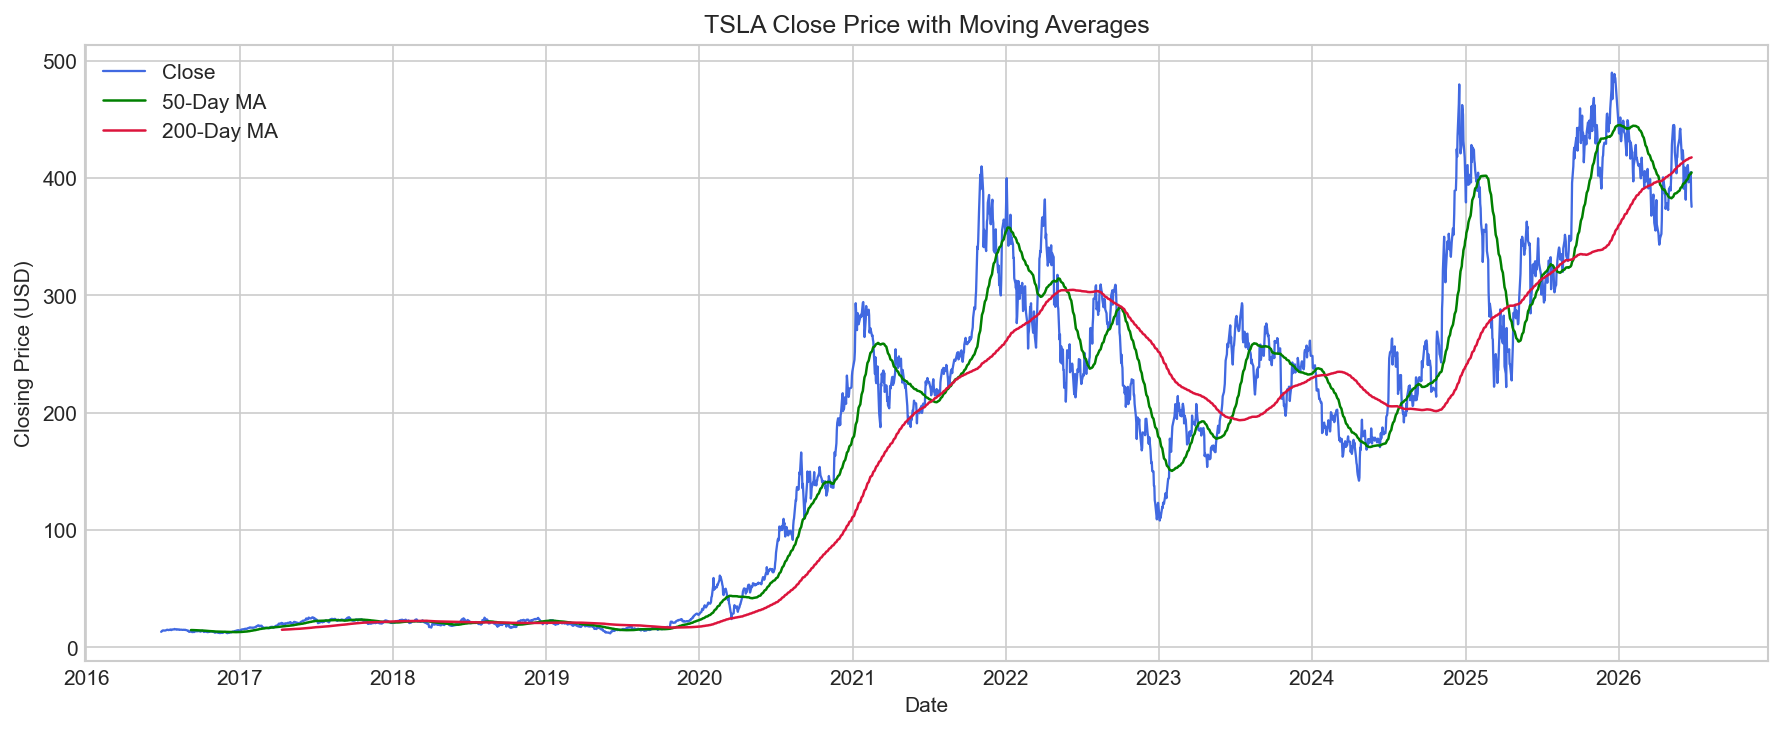

In [4]:
def save_current_plot(filename):
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()


fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(data.index, data["Close"], color="royalblue", linewidth=1.5)
ax.set_title("TSLA Closing Price Trend")
ax.set_xlabel("Date")
ax.set_ylabel("Closing Price (USD)")
save_current_plot("tsla_01_close_price_trend.png")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(data.index, data["Volume"], color="darkorange", linewidth=1.0)
ax.set_title("TSLA Trading Volume Trend")
ax.set_xlabel("Date")
ax.set_ylabel("Volume")
save_current_plot("tsla_02_volume_trend.png")

moving_average_data = data[["Close"]].copy()
moving_average_data["MA_50"] = moving_average_data["Close"].rolling(50).mean()
moving_average_data["MA_200"] = moving_average_data["Close"].rolling(200).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(moving_average_data.index, moving_average_data["Close"], label="Close", color="royalblue", linewidth=1.1)
ax.plot(moving_average_data.index, moving_average_data["MA_50"], label="50-Day MA", color="green", linewidth=1.2)
ax.plot(moving_average_data.index, moving_average_data["MA_200"], label="200-Day MA", color="crimson", linewidth=1.2)
ax.set_title("TSLA Close Price with Moving Averages")
ax.set_xlabel("Date")
ax.set_ylabel("Closing Price (USD)")
ax.legend()
save_current_plot("tsla_03_moving_averages.png")


## 4. RNN Technique Used

The required RNN-based method is an LSTM network. LSTM is suitable for time-series forecasting because it processes ordered sequences and uses gates to retain or discard information from earlier time steps. In this notebook, each sample contains the previous 60 trading days of engineered market features, and the model predicts the next trading day's return before converting that return back into a closing price.


## 5. Feature Engineering

The prediction target is the next trading day's closing price. The model predicts next-day return instead of raw price because returns are usually more stable across long time periods. The predicted return is later converted back into a price forecast.


In [5]:
def compute_rsi(close, window=14):
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def build_feature_frame(price_data):
    frame = price_data.copy()
    frame["Daily_Return"] = frame["Close"].pct_change()
    frame["High_Low_Range"] = (frame["High"] - frame["Low"]) / frame["Close"]
    frame["Open_Close_Change"] = (frame["Close"] - frame["Open"]) / frame["Open"]
    frame["Volume_Change"] = frame["Volume"].pct_change()
    frame["MA_10"] = frame["Close"].rolling(10).mean()
    frame["MA_20"] = frame["Close"].rolling(20).mean()
    frame["MA_50"] = frame["Close"].rolling(50).mean()
    frame["Close_to_MA_10"] = frame["Close"] / frame["MA_10"] - 1
    frame["Close_to_MA_20"] = frame["Close"] / frame["MA_20"] - 1
    frame["Close_to_MA_50"] = frame["Close"] / frame["MA_50"] - 1
    frame["Volatility_10"] = frame["Daily_Return"].rolling(10).std()
    frame["Volatility_20"] = frame["Daily_Return"].rolling(20).std()
    frame["RSI_14"] = compute_rsi(frame["Close"], 14)
    return frame.replace([np.inf, -np.inf], np.nan)


def build_modeling_frame(price_data):
    frame = build_feature_frame(price_data)
    frame["Target_Next_Close"] = frame["Close"].shift(-1)
    frame["Target_Next_Return"] = frame["Target_Next_Close"] / frame["Close"] - 1
    frame["Target_Date"] = pd.Series(frame.index, index=frame.index).shift(-1)
    return frame.dropna()


modeling_data = build_modeling_frame(data)

feature_columns = [
    "Open", "High", "Low", "Close", "Adj Close", "Volume",
    "Daily_Return", "High_Low_Range", "Open_Close_Change", "Volume_Change",
    "MA_10", "MA_20", "MA_50",
    "Close_to_MA_10", "Close_to_MA_20", "Close_to_MA_50",
    "Volatility_10", "Volatility_20", "RSI_14",
]

target_column = "Target_Next_Return"

print(f"Modeling rows after feature engineering: {len(modeling_data):,}")
print(f"Number of input features: {len(feature_columns)}")
display(modeling_data[feature_columns + ["Target_Next_Close", target_column, "Target_Date"]].head())


Modeling rows after feature engineering: 2,462
Number of input features: 19


,Open,High,Low,Close,Adj Close,Volume,Daily_Return,High_Low_Range,Open_Close_Change,Volume_Change,MA_10,MA_20,MA_50,Close_to_MA_10,Close_to_MA_20,Close_to_MA_50,Volatility_10,Volatility_20,RSI_14,Target_Next_Close,Target_Next_Return,Target_Date
Date,,,,,,,,,,,,,,,,,,,,,,
2016-09-06,13.2680,13.5500,13.2667,13.5220,13.5220,65859000,0.0255,0.0210,0.0191,-0.2655,14.1889,14.5916,14.7169,-0.0470,-0.0733,-0.0812,0.0208,0.0159,23.7361,13.4473,-0.0055,2016-09-07
2016-09-07,13.7000,13.7667,13.3807,13.4473,13.4473,54613500,-0.0055,0.0287,-0.0184,-0.1708,14.0347,14.5003,14.7211,-0.0419,-0.0726,-0.0865,0.0199,0.0153,23.2945,13.1573,-0.0216,2016-09-08
2016-09-08,13.3033,13.3260,13.0907,13.1573,13.1573,50668500,-0.0216,0.0179,-0.0110,-0.0722,13.8663,14.4060,14.7152,-0.0511,-0.0867,-0.1059,0.0202,0.0156,20.5452,12.9647,-0.0146,2016-09-09
2016-09-09,13.2727,13.3280,12.9133,12.9647,12.9647,56355000,-0.0146,0.0320,-0.0232,0.1122,13.6897,14.3046,14.6942,-0.0530,-0.0937,-0.1177,0.0202,0.0156,16.6630,13.2200,0.0197,2016-09-12
2016-09-12,13.0000,13.4247,12.9400,13.2200,13.2200,55728000,0.0197,0.0367,0.0169,-0.0111,13.5451,14.2135,14.6756,-0.0240,-0.0699,-0.0992,0.0225,0.0166,24.1009,13.0700,-0.0113,2016-09-13


## 6. Chronological Split and Sequence Preparation

Financial time-series data must be split chronologically. Random splitting would leak future market conditions into training. The split used here is 70% training, 15% validation, and 15% testing.


In [6]:
LOOKBACK = 60
TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15

n_rows = len(modeling_data)
train_end = int(n_rows * TRAIN_RATIO)
validation_end = int(n_rows * (TRAIN_RATIO + VALIDATION_RATIO))

feature_scaler = MinMaxScaler()
target_scaler = StandardScaler()

feature_scaler.fit(modeling_data.iloc[:train_end][feature_columns])
target_scaler.fit(modeling_data.iloc[:train_end][[target_column]])

scaled_features = feature_scaler.transform(modeling_data[feature_columns])
scaled_target = target_scaler.transform(modeling_data[[target_column]]).ravel()


def create_lstm_sequences(features, target, dates, current_close, lookback):
    X, y, target_dates, previous_closes, row_indices = [], [], [], [], []
    for end_idx in range(lookback - 1, len(features)):
        start_idx = end_idx - lookback + 1
        X.append(features[start_idx:end_idx + 1])
        y.append(target[end_idx])
        target_dates.append(dates.iloc[end_idx])
        previous_closes.append(current_close.iloc[end_idx])
        row_indices.append(end_idx)
    return (
        np.array(X),
        np.array(y),
        pd.to_datetime(pd.Series(target_dates)),
        np.array(previous_closes),
        np.array(row_indices),
    )


X_all, y_all, target_dates_all, previous_close_all, row_indices = create_lstm_sequences(
    scaled_features,
    scaled_target,
    modeling_data["Target_Date"],
    modeling_data["Close"],
    LOOKBACK,
)

train_mask = row_indices < train_end
validation_mask = (row_indices >= train_end) & (row_indices < validation_end)
test_mask = row_indices >= validation_end

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val, y_val = X_all[validation_mask], y_all[validation_mask]
X_test, y_test = X_all[test_mask], y_all[test_mask]

test_dates = target_dates_all[test_mask].reset_index(drop=True)
test_previous_close = previous_close_all[test_mask]

split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Sequences": [len(X_train), len(X_val), len(X_test)],
    "Target Start": [
        target_dates_all[train_mask].min().date(),
        target_dates_all[validation_mask].min().date(),
        target_dates_all[test_mask].min().date(),
    ],
    "Target End": [
        target_dates_all[train_mask].max().date(),
        target_dates_all[validation_mask].max().date(),
        target_dates_all[test_mask].max().date(),
    ],
})

display(split_summary)
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)


X_train shape: (1664, 60, 19)
X_val shape: (369, 60, 19)
X_test shape: (370, 60, 19)


,Split,Sequences,Target Start,Target End
0,Train,1664,2016-11-30,2023-07-13
1,Validation,369,2023-07-14,2024-12-30
2,Test,370,2024-12-31,2026-06-24


## 7. LSTM Model Development

The LSTM receives a 60-day sequence of TSLA features and outputs one scaled next-day return. Dropout, validation monitoring, early stopping, and learning-rate reduction are used to reduce overfitting risk.


In [7]:
def build_lstm_model(lookback, n_features):
    model = Sequential([
        Input(shape=(lookback, n_features)),
        LSTM(64, return_sequences=True),
        Dropout(0.20),
        LSTM(32),
        Dropout(0.20),
        Dense(16, activation="relu"),
        Dense(1),
    ])
    model.compile(optimizer="adam", loss=tf.keras.losses.Huber())
    return model


lstm_model = build_lstm_model(LOOKBACK, X_train.shape[2])
lstm_model.summary()


Model: "sequential"
┌─────────────────────────────────┬────────────────────────┬───────────────┐
│ Layer (type)                    │ Output Shape           │       Param # │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 60, 64)         │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼─────────────────────

## 8. Model Training

The model is trained only on historical training sequences and monitored on the validation period. The test period remains untouched until final evaluation.


,Metric,Value
0,Epochs Trained,18.0000
1,Final Training Loss,0.3748
2,Best Validation Loss,0.3611


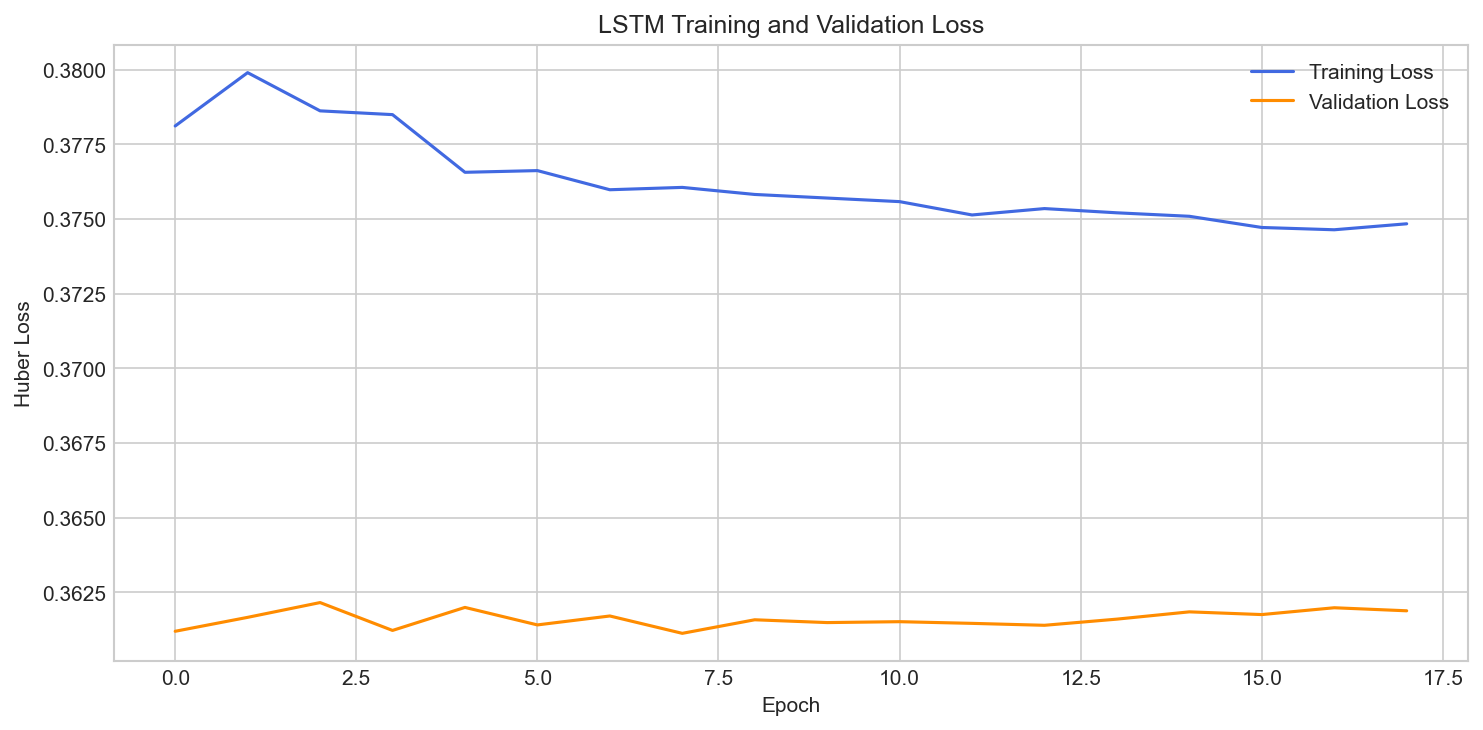

In [8]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5,
)

history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=32,
    shuffle=False,
    callbacks=[early_stopping, reduce_lr],
    verbose=0,
)

training_summary = pd.DataFrame({
    "Metric": ["Epochs Trained", "Final Training Loss", "Best Validation Loss"],
    "Value": [
        len(history.history["loss"]),
        history.history["loss"][-1],
        min(history.history["val_loss"]),
    ],
})
display(training_summary)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history["loss"], label="Training Loss", color="royalblue")
ax.plot(history.history["val_loss"], label="Validation Loss", color="darkorange")
ax.set_title("LSTM Training and Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Huber Loss")
ax.legend()
save_current_plot("tsla_04_lstm_training_loss.png")


## 9. Evaluation and Alternative Model Comparison

The LSTM is evaluated on the chronological test period. It is compared against a previous-close baseline and a Random Forest Regressor alternative model.


In [9]:
def inverse_target(values):
    return target_scaler.inverse_transform(np.asarray(values).reshape(-1, 1)).ravel()


def calculate_metrics(actual, predicted, previous_close):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    previous_close = np.asarray(previous_close)
    direction_actual = np.sign(actual - previous_close)
    direction_predicted = np.sign(predicted - previous_close)
    direction_accuracy = np.mean(direction_actual == direction_predicted) * 100
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "R2 Score": r2_score(actual, predicted),
        "MAPE (%)": np.mean(np.abs((actual - predicted) / actual)) * 100,
        "Direction Accuracy (%)": direction_accuracy,
    }


lstm_pred_scaled = lstm_model.predict(X_test, verbose=0).ravel()
lstm_pred_return = inverse_target(lstm_pred_scaled)
actual_return = inverse_target(y_test)

actual_prices = test_previous_close * (1 + actual_return)
lstm_pred = test_previous_close * (1 + lstm_pred_return)
baseline_pred = test_previous_close.copy()

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
rf_model.fit(X_train[:, -1, :], y_train)
rf_pred_return = inverse_target(rf_model.predict(X_test[:, -1, :]))
rf_pred = test_previous_close * (1 + rf_pred_return)

metrics_df = pd.DataFrame({
    "Previous-Close Baseline": calculate_metrics(actual_prices, baseline_pred, test_previous_close),
    "Random Forest Alternative": calculate_metrics(actual_prices, rf_pred, test_previous_close),
    "LSTM RNN": calculate_metrics(actual_prices, lstm_pred, test_previous_close),
}).T

metrics_df = metrics_df.sort_values("RMSE")
display(metrics_df)


,MAE,RMSE,R2 Score,MAPE (%),Direction Accuracy (%)
LSTM RNN,9.4496,12.1502,0.9633,2.6464,50.2703
Previous-Close Baseline,9.4438,12.1711,0.9632,2.6469,0.0000
Random Forest Alternative,12.7647,16.5036,0.9323,3.3853,50.5405


## 10. Forecast Visualizations

The following plots show test-period prediction quality and LSTM error behavior.


,Date,Previous Close,Actual Next Close,Previous-Close Baseline,Random Forest Prediction,LSTM Prediction,LSTM Error,LSTM Absolute Error,LSTM Percentage Error (%)
0,2024-12-31,417.4100,403.8400,417.4100,403.6286,417.0083,-13.1683,13.1683,3.2608
1,2025-01-02,403.8400,379.2800,403.8400,389.5948,403.4258,-24.1458,24.1458,6.3662
2,2025-01-03,379.2800,410.4400,379.2800,371.6367,378.8643,31.5757,31.5757,7.6931
3,2025-01-06,410.4400,411.0500,410.4400,395.6055,409.9708,1.0792,1.0792,0.2625
4,2025-01-07,411.0500,394.3600,411.0500,395.1119,410.5626,-16.2026,16.2026,4.1086
5,2025-01-08,394.3600,394.9400,394.3600,383.1076,393.8690,1.0710,1.0710,0.2712
6,2025-01-10,394.9400,394.7400,394.9400,379.0876,394.4188,0.3212,0.3212,0.0814
7,2025-01-13,394.7400,403.3100,394.7400,381.6715,394.1952,9.1148,9.1148,2.2600
8,2025-01-14,403.3100,396.3600,403.3100,386.3836,402.7298,-6.3698,6.3698,1.6071
9,2025-01-15,396.3600,428.2200,396.3600,381.7130,395.7793,32.4407,32.4407,7.5757


,Date,Previous Close,Actual Next Close,Previous-Close Baseline,Random Forest Prediction,LSTM Prediction,LSTM Error,LSTM Absolute Error,LSTM Percentage Error (%)
360,2026-06-10,396.6800,381.5900,396.6800,382.4580,396.0325,-14.4426,14.4426,3.7848
361,2026-06-11,381.5900,399.1500,381.5900,371.9951,380.9680,18.1819,18.1819,4.5552
362,2026-06-12,399.1500,406.4300,399.1500,384.6559,398.5035,7.9265,7.9265,1.9503
363,2026-06-15,406.4300,411.1500,406.4300,387.4838,405.7744,5.3756,5.3756,1.3075
364,2026-06-16,411.1500,404.6600,411.1500,399.7110,410.4820,-5.8220,5.8220,1.4387
365,2026-06-17,404.6600,396.3800,404.6600,399.7228,403.9912,-7.6112,7.6112,1.9202
366,2026-06-18,396.3800,400.4900,396.3800,383.5322,395.7130,4.7770,4.7770,1.1928
367,2026-06-22,400.4900,405.0500,400.4900,382.2293,399.8099,5.2401,5.2401,1.2937
368,2026-06-23,405.0500,381.6100,405.0500,390.1713,404.3593,-22.7493,22.7493,5.9614
369,2026-06-24,381.6100,375.5300,381.6100,367.6642,380.9535,-5.4235,5.4235,1.4442


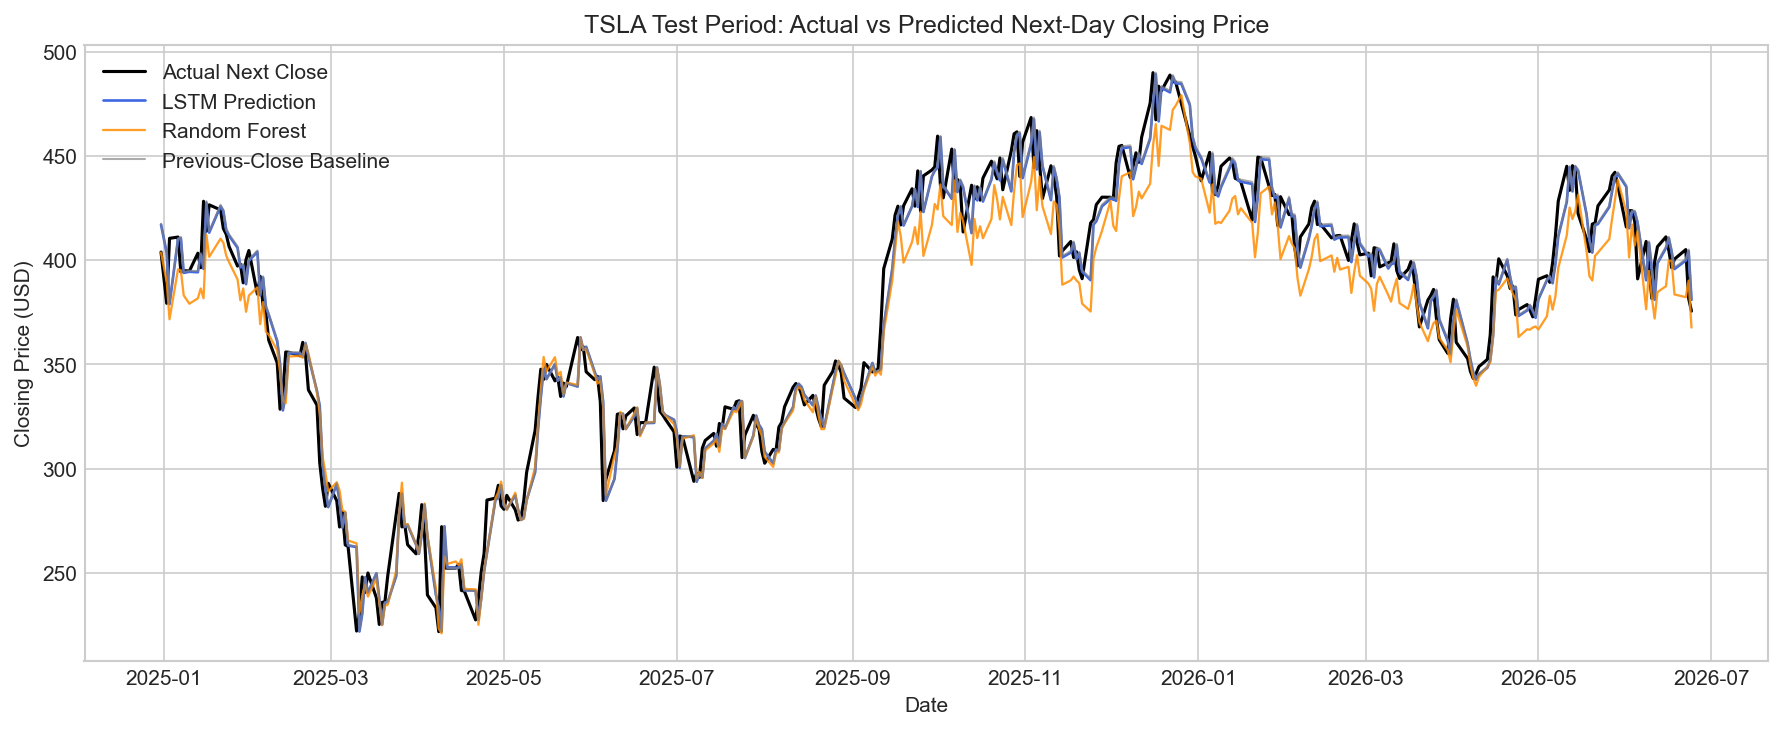

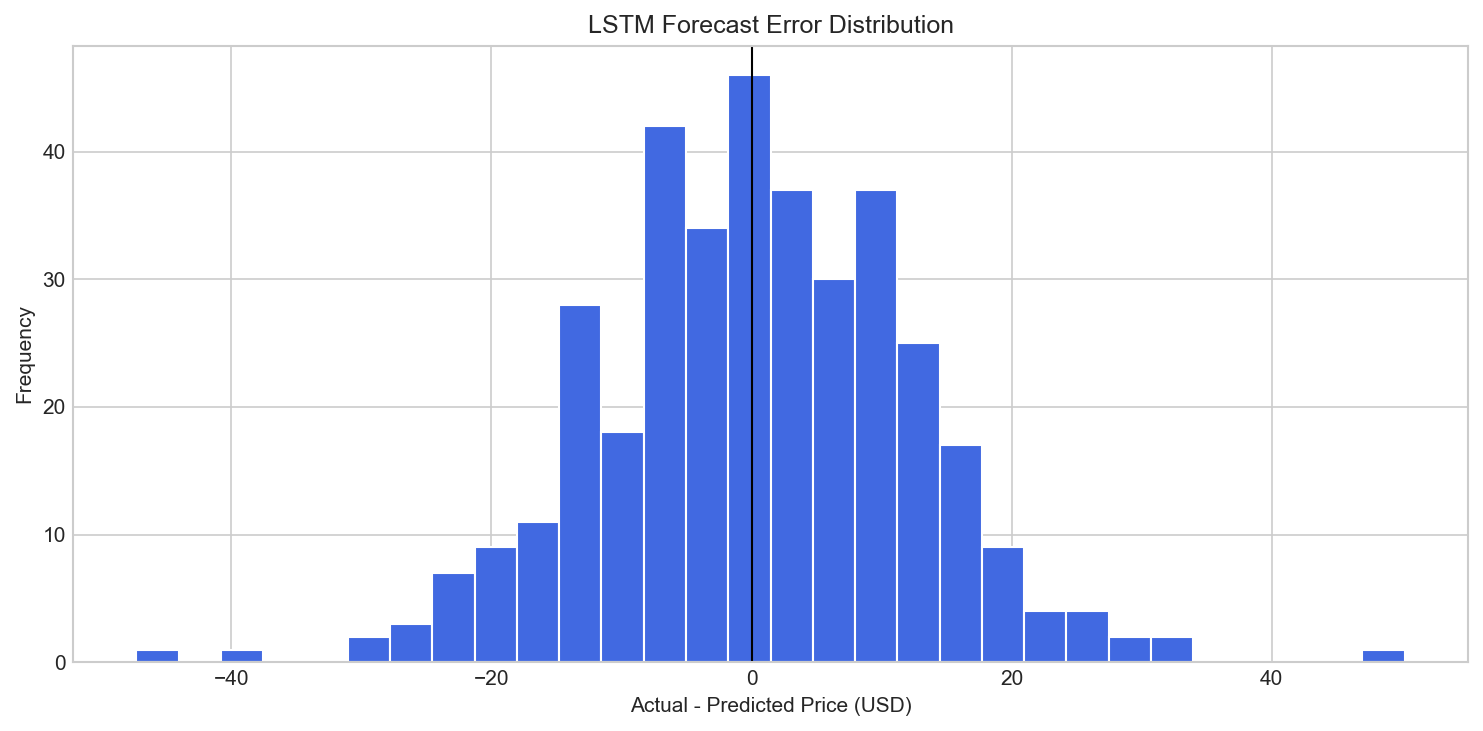

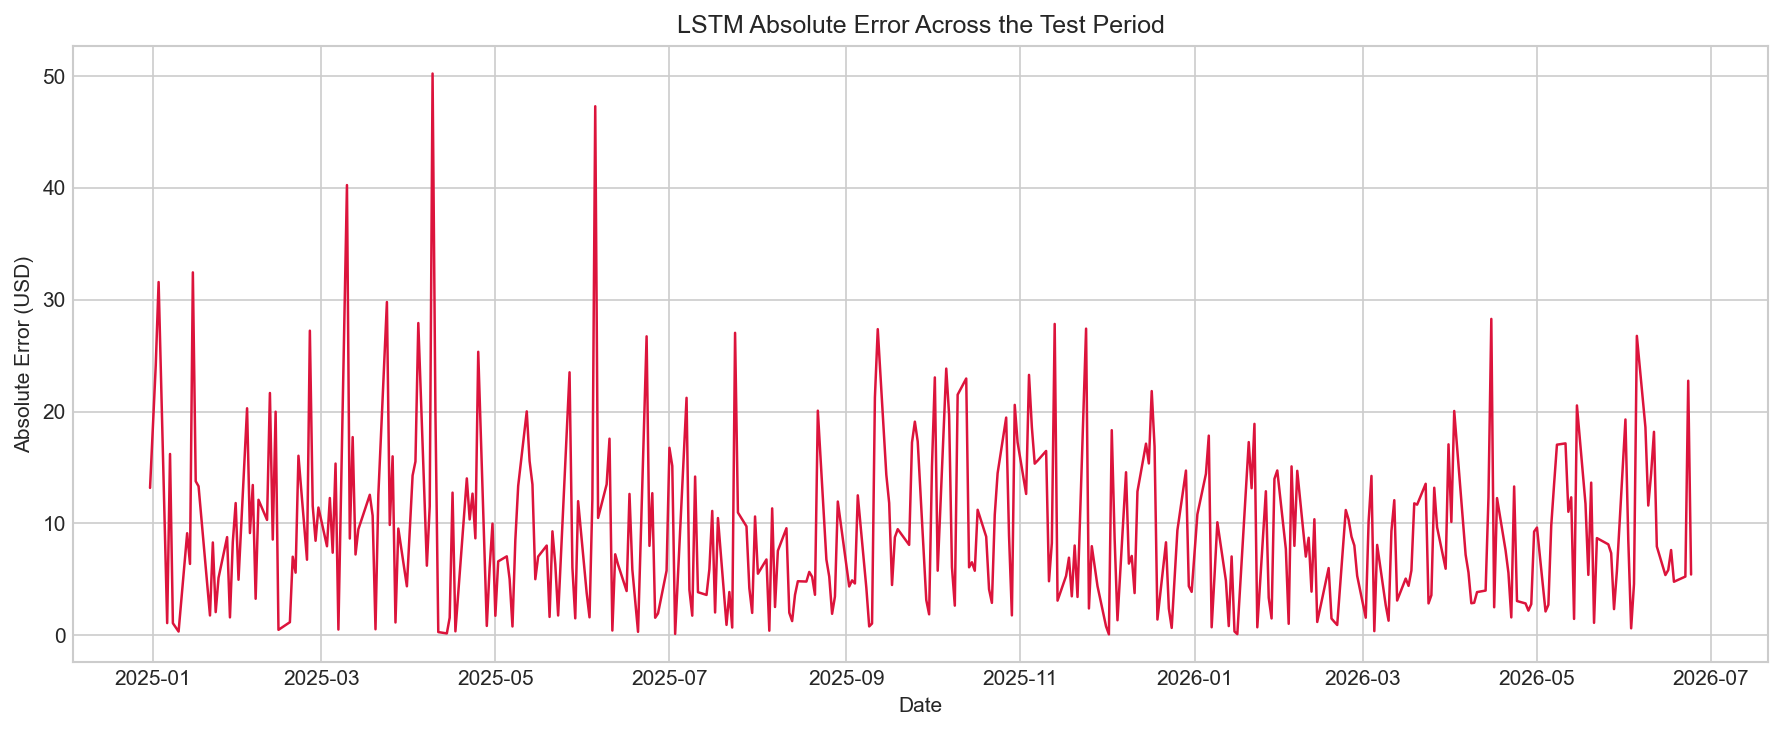

In [10]:
results_df = pd.DataFrame({
    "Date": test_dates,
    "Previous Close": test_previous_close,
    "Actual Next Close": actual_prices,
    "Previous-Close Baseline": baseline_pred,
    "Random Forest Prediction": rf_pred,
    "LSTM Prediction": lstm_pred,
})

results_df["LSTM Error"] = results_df["Actual Next Close"] - results_df["LSTM Prediction"]
results_df["LSTM Absolute Error"] = results_df["LSTM Error"].abs()
results_df["LSTM Percentage Error (%)"] = (
    results_df["LSTM Absolute Error"] / results_df["Actual Next Close"].abs()
) * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_df["Date"], results_df["Actual Next Close"], label="Actual Next Close", color="black", linewidth=1.5)
ax.plot(results_df["Date"], results_df["LSTM Prediction"], label="LSTM Prediction", color="royalblue", linewidth=1.3)
ax.plot(results_df["Date"], results_df["Random Forest Prediction"], label="Random Forest", color="darkorange", linewidth=1.1, alpha=0.85)
ax.plot(results_df["Date"], results_df["Previous-Close Baseline"], label="Previous-Close Baseline", color="gray", linewidth=1.0, alpha=0.65)
ax.set_title("TSLA Test Period: Actual vs Predicted Next-Day Closing Price")
ax.set_xlabel("Date")
ax.set_ylabel("Closing Price (USD)")
ax.legend()
save_current_plot("tsla_05_actual_vs_predicted.png")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(results_df["LSTM Error"], bins=30, color="royalblue", edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
ax.set_title("LSTM Forecast Error Distribution")
ax.set_xlabel("Actual - Predicted Price (USD)")
ax.set_ylabel("Frequency")
save_current_plot("tsla_06_lstm_error_distribution.png")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_df["Date"], results_df["LSTM Absolute Error"], color="crimson", linewidth=1.2)
ax.set_title("LSTM Absolute Error Across the Test Period")
ax.set_xlabel("Date")
ax.set_ylabel("Absolute Error (USD)")
save_current_plot("tsla_07_lstm_absolute_error.png")

display(results_df.head(10))
display(results_df.tail(10))


## 11. Latest Next-Day Forecast

This cell uses the most recent 60 available trading days to produce the next estimated TSLA closing price.


In [ ]:
latest_feature_frame = build_feature_frame(data).replace([np.inf, -np.inf], np.nan).dropna()
latest_feature_values = feature_scaler.transform(latest_feature_frame[feature_columns])
latest_sequence = latest_feature_values[-LOOKBACK:].reshape(1, LOOKBACK, len(feature_columns))

latest_date = latest_feature_frame.index[-1]
latest_close = data.loc[latest_date, "Close"]
estimated_next_business_day = latest_date + pd.offsets.BDay(1)

next_return_prediction = inverse_target(lstm_model.predict(latest_sequence, verbose=0))[0]
next_close_prediction = latest_close * (1 + next_return_prediction)

next_day_forecast = pd.DataFrame({
    "Latest Available Date": [latest_date.date()],
    "Estimated Next Business Day": [estimated_next_business_day.date()],
    "Latest Close (USD)": [latest_close],
    "Predicted Next Close (USD)": [next_close_prediction],
    "Predicted Change (USD)": [next_close_prediction - latest_close],
    "Predicted Change (%)": [(next_close_prediction - latest_close) / latest_close * 100],
})

display(next_day_forecast)


,Latest Available Date,Estimated Next Business Day,Latest Close (USD),Predicted Next Close (USD),Predicted Change (USD),Predicted Change (%)
0,2026-06-24,2026-06-25,375.5300,374.8801,-0.6499,-0.1731


## 12. Optional Appendix: Investment Simulation

This section is included only as an optional illustrative simulation. It is not used as the main model evaluation and should not be interpreted as financial advice or a real trading strategy.

The simulation turns the LSTM forecast into a simple buy-low-sell-high rule. If the predicted next close is higher than the current close, the strategy buys TSLA at the current close and sells at the actual next close. If the model predicts a lower or unchanged close, the strategy stays in cash.

Assumptions: no transaction costs, no slippage, no taxes, fractional shares allowed, and each trade uses the full available portfolio value.


,Strategy,Initial Capital (USD),Final Equity (USD),Final PnL (USD),Total Return (%),Number of Trades,Win Rate (%),Max Drawdown (%)
0,LSTM Buy/Sell Rule,"10,000.0000","13,223.1053","3,223.1053",32.2311,43,53.4884,-21.5377
1,Buy and Hold,"10,000.0000","8,996.6698","-1,003.3302",-10.0333,1,NaN,-48.1902


,Date,Previous Close,Actual Next Close,LSTM Prediction,LSTM Signal,Market Return,Strategy Return,Trade PnL,Strategy Equity
360,2026-06-10,396.6800,381.5900,396.0325,0,-0.0380,-0.0000,0.0000,"13,223.1053"
361,2026-06-11,381.5900,399.1500,380.9680,0,0.0460,0.0000,0.0000,"13,223.1053"
362,2026-06-12,399.1500,406.4300,398.5035,0,0.0182,0.0000,0.0000,"13,223.1053"
363,2026-06-15,406.4300,411.1500,405.7744,0,0.0116,0.0000,0.0000,"13,223.1053"
364,2026-06-16,411.1500,404.6600,410.4820,0,-0.0158,-0.0000,0.0000,"13,223.1053"
365,2026-06-17,404.6600,396.3800,403.9912,0,-0.0205,-0.0000,0.0000,"13,223.1053"
366,2026-06-18,396.3800,400.4900,395.7130,0,0.0104,0.0000,0.0000,"13,223.1053"
367,2026-06-22,400.4900,405.0500,399.8099,0,0.0114,0.0000,0.0000,"13,223.1053"
368,2026-06-23,405.0500,381.6100,404.3593,0,-0.0579,-0.0000,0.0000,"13,223.1053"
369,2026-06-24,381.6100,375.5300,380.9535,0,-0.0159,-0.0000,0.0000,"13,223.1053"


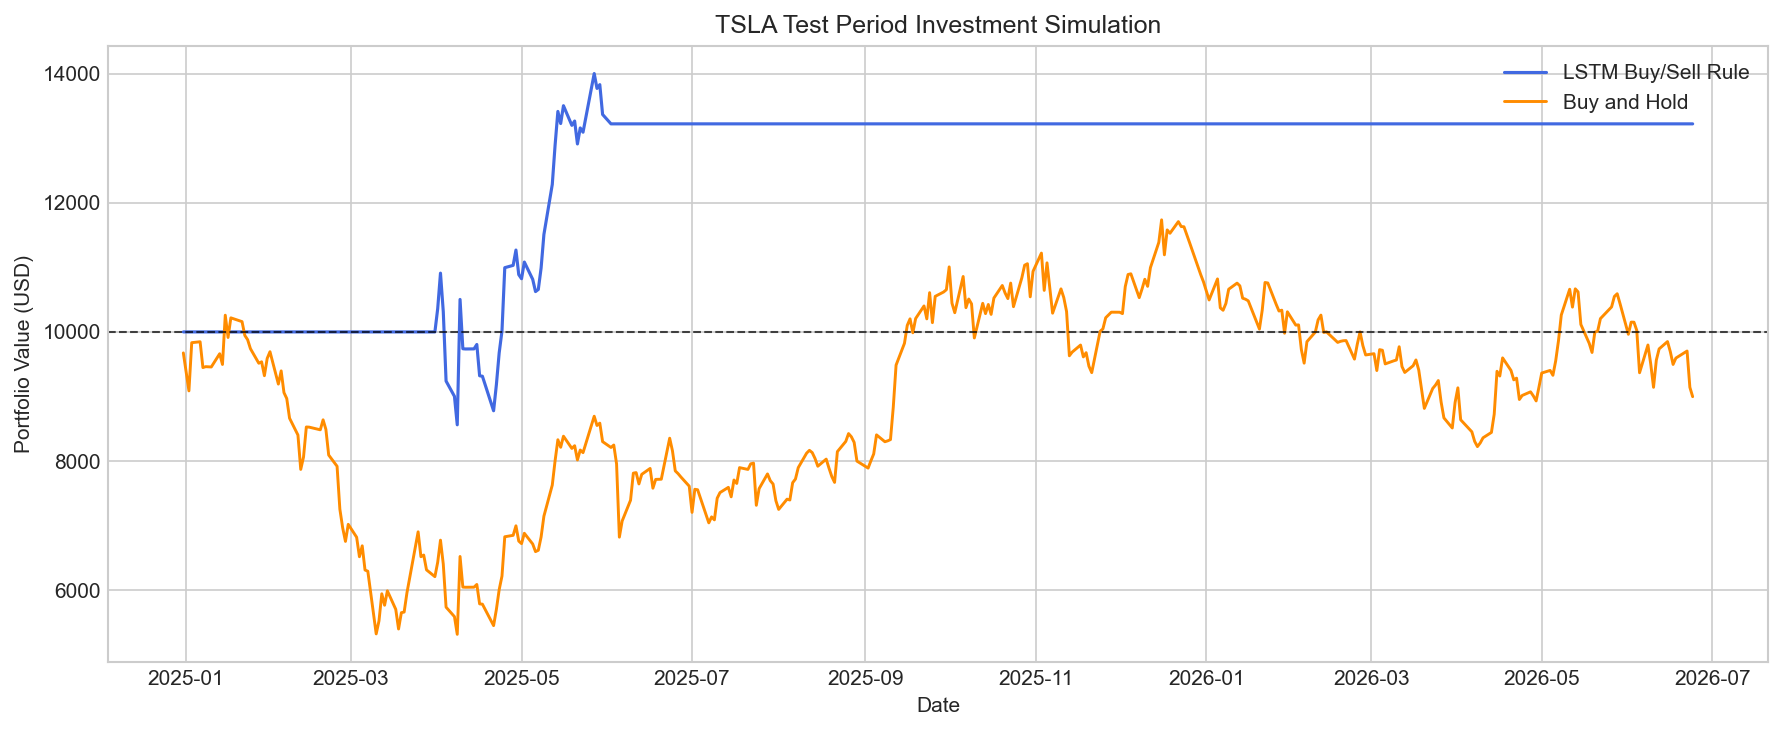

In [12]:
INITIAL_CAPITAL = 10_000.00

trading_df = results_df.copy()
trading_df["LSTM Signal"] = np.where(
    trading_df["LSTM Prediction"] > trading_df["Previous Close"],
    1,
    0,
)
trading_df["Market Return"] = trading_df["Actual Next Close"] / trading_df["Previous Close"] - 1
trading_df["Strategy Return"] = trading_df["LSTM Signal"] * trading_df["Market Return"]
trading_df["Strategy Equity"] = INITIAL_CAPITAL * (1 + trading_df["Strategy Return"]).cumprod()
trading_df["Buy and Hold Equity"] = INITIAL_CAPITAL * (1 + trading_df["Market Return"]).cumprod()
trading_df["Trade PnL"] = trading_df["Strategy Equity"].diff().fillna(
    trading_df["Strategy Equity"] - INITIAL_CAPITAL
)


def max_drawdown(equity_curve):
    running_peak = equity_curve.cummax()
    drawdown = equity_curve / running_peak - 1
    return drawdown.min() * 100


trade_rows = trading_df[trading_df["LSTM Signal"] == 1]
winning_trades = (trade_rows["Strategy Return"] > 0).sum()
trade_count = len(trade_rows)
win_rate = winning_trades / trade_count * 100 if trade_count else 0

strategy_final_equity = trading_df["Strategy Equity"].iloc[-1]
buy_hold_final_equity = trading_df["Buy and Hold Equity"].iloc[-1]

simulation_summary = pd.DataFrame({
    "Strategy": ["LSTM Buy/Sell Rule", "Buy and Hold"],
    "Initial Capital (USD)": [INITIAL_CAPITAL, INITIAL_CAPITAL],
    "Final Equity (USD)": [strategy_final_equity, buy_hold_final_equity],
    "Final PnL (USD)": [strategy_final_equity - INITIAL_CAPITAL, buy_hold_final_equity - INITIAL_CAPITAL],
    "Total Return (%)": [
        (strategy_final_equity / INITIAL_CAPITAL - 1) * 100,
        (buy_hold_final_equity / INITIAL_CAPITAL - 1) * 100,
    ],
    "Number of Trades": [trade_count, 1],
    "Win Rate (%)": [win_rate, np.nan],
    "Max Drawdown (%)": [
        max_drawdown(trading_df["Strategy Equity"]),
        max_drawdown(trading_df["Buy and Hold Equity"]),
    ],
})

display(simulation_summary)

display_columns = [
    "Date",
    "Previous Close",
    "Actual Next Close",
    "LSTM Prediction",
    "LSTM Signal",
    "Market Return",
    "Strategy Return",
    "Trade PnL",
    "Strategy Equity",
]
display(trading_df[display_columns].tail(10))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(trading_df["Date"], trading_df["Strategy Equity"], label="LSTM Buy/Sell Rule", color="royalblue", linewidth=1.5)
ax.plot(trading_df["Date"], trading_df["Buy and Hold Equity"], label="Buy and Hold", color="darkorange", linewidth=1.4)
ax.axhline(INITIAL_CAPITAL, color="black", linestyle="--", linewidth=1, alpha=0.7)
ax.set_title("TSLA Test Period Investment Simulation")
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value (USD)")
ax.legend()
save_current_plot("tsla_08_trading_simulation_equity.png")


## 13. Source Code

GitHub repository: https://github.com/BingJun69/ML_Final_Assesment

The notebook contains the complete source code workflow for TSLA data download, preprocessing, feature engineering, LSTM model training, benchmark comparison, evaluation, and visualisation.
